In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from master_thesis.deep_learning.explainability.pretraining.local import explain_patient
import os
import re
from master_thesis.deep_learning.utils import load_config
from master_thesis.deep_learning.data import ECGDataset
from master_thesis.deep_learning.models.ecg_model import ECGModel
from torch.utils.data import DataLoader
import torch
from master_thesis.deep_learning.explainability.visualization import plot_local_explanation
from matplotlib import pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# loading all models for 5 seeds both for pretrained and finetuned models
checkpoint_dirs = os.listdir("../checkpoints")
bigru_pattern = re.compile(r"^bigru_fusion_(?:pretrain|finetune)_\d+$")
cnn_lstm_pattern = re.compile(r"^cnn_lstm_fusion_(?:pretrain|finetune)_\d+$")
matching_dirs = [
    d for d in checkpoint_dirs
    if bigru_pattern.match(d) or cnn_lstm_pattern.match(d)
]
models = {
    "model_type": [],
    "train_stage": [],
    "seed": [],
    "model_path": [],
}
for dir_name in matching_dirs:
    model_type = "gru" if "bigru" in dir_name else "cnn_lstm"
    train_stage = "pretrain" if "pretrain" in dir_name else "finetune"
    seed = int(dir_name.split("_")[-1])
    model_path = f"../checkpoints/{dir_name}/best.pt"
    models["model_type"].append(model_type)
    models["train_stage"].append(train_stage)
    models["seed"].append(seed)
    models["model_path"].append(model_path)

In [5]:
SELECTED_SEED = 123
MODEL_TYPE = "gru"  # or "cnn_lstm"

In [6]:
bigru_pretrain_config = load_config("../configs/15_bigru_fusion_pretrain_123.yaml")
bigru_finetune_config = load_config("../configs/20_bigru_fusion_finetune_123.yaml")
cnn_lstm_pretrain_config = load_config(
    "../configs/25_cnn_lstm_fusion_pretrain_123.yaml"
)
cnn_lstm_finetune_config = load_config(
    "../configs/30_cnn_lstm_fusion_finetune_123.yaml"
)

CONFIG_MAP = {
    ("gru", "pretrain"): bigru_pretrain_config,
    ("gru", "finetune"): bigru_finetune_config,
    ("cnn_lstm", "pretrain"): cnn_lstm_pretrain_config,
    ("cnn_lstm", "finetune"): cnn_lstm_finetune_config,
}

common_tabular_features = [
    "sex",
    "ventricular_rate",
    "atrial_rate",
    "pr_interval",
    "qrs_duration",
    "qt_corrected",
    "age_at_ecg",
]

In [7]:
dataset_args = {
    "waveforms_path": "../data/EchoNext_test_waveforms.npy",
    "metadata_path": "../data/echonext_metadata_100k.csv",
    "split": "test",
    "tabular_path": "../data/EchoNext_test_tabular_features.npy",
    "tabular_features": common_tabular_features,
}
batch_size = 32
num_workers = 4

pretrain_dataset = ECGDataset(**dataset_args, pretrain=True)
pretrain_loader = DataLoader(
    pretrain_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

finetune_dataset = ECGDataset(**dataset_args, pretrain=False)
finetune_loader = DataLoader(
    finetune_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

In [8]:
pretrain_diseases = list(pretrain_dataset.label_columns)
finetune_diseases = [
    d
    for d in finetune_dataset.label_columns
    if d != "shd_moderate_or_greater_flag"
]

In [9]:
model = ECGModel(diseases=pretrain_diseases, config=CONFIG_MAP[(MODEL_TYPE, "pretrain")])
for model_type, train_stage, seed, model_path in zip(
    models["model_type"],
    models["train_stage"],
    models["seed"],
    models["model_path"],
):
    if model_type == MODEL_TYPE and seed == SELECTED_SEED and train_stage == "pretrain":
        model.load_state_dict(torch.load(model_path, map_location=device)["model_state_dict"])
        model.to(device)
        model.eval()
        print(f"Loaded {train_stage} model for {model_type} with seed {seed} from {model_path}")

Loaded pretrain model for gru with seed 123 from ../checkpoints/bigru_fusion_pretrain_123/best.pt


In [10]:
from master_thesis.deep_learning.explainability.pretraining.utils import (
    find_prediction_cases,
    summarize_prediction_cases,
    get_representative_cases,
)

cases = find_prediction_cases(
    model=model,
    dataset=pretrain_dataset,
    device=device,
    threshold=0.4,
)

summarize_prediction_cases(cases)

Prediction case summary
true_positive     : 1704
true_negative     : 2386
false_positive    : 738
false_negative    : 614


In [11]:
representative = get_representative_cases(
    cases,
    n=1,
)

In [12]:
representative

{'true_positive': [{'index': 1872,
   'true_label': 1.0,
   'probability': 0.9981666803359985,
   'prediction': 1}],
 'true_negative': [{'index': 1190,
   'true_label': 0.0,
   'probability': 0.011384307406842709,
   'prediction': 0}],
 'false_positive': [{'index': 3740,
   'true_label': 0.0,
   'probability': 0.9976397752761841,
   'prediction': 1}],
 'false_negative': [{'index': 3349,
   'true_label': 1.0,
   'probability': 0.015459779649972916,
   'prediction': 0}]}

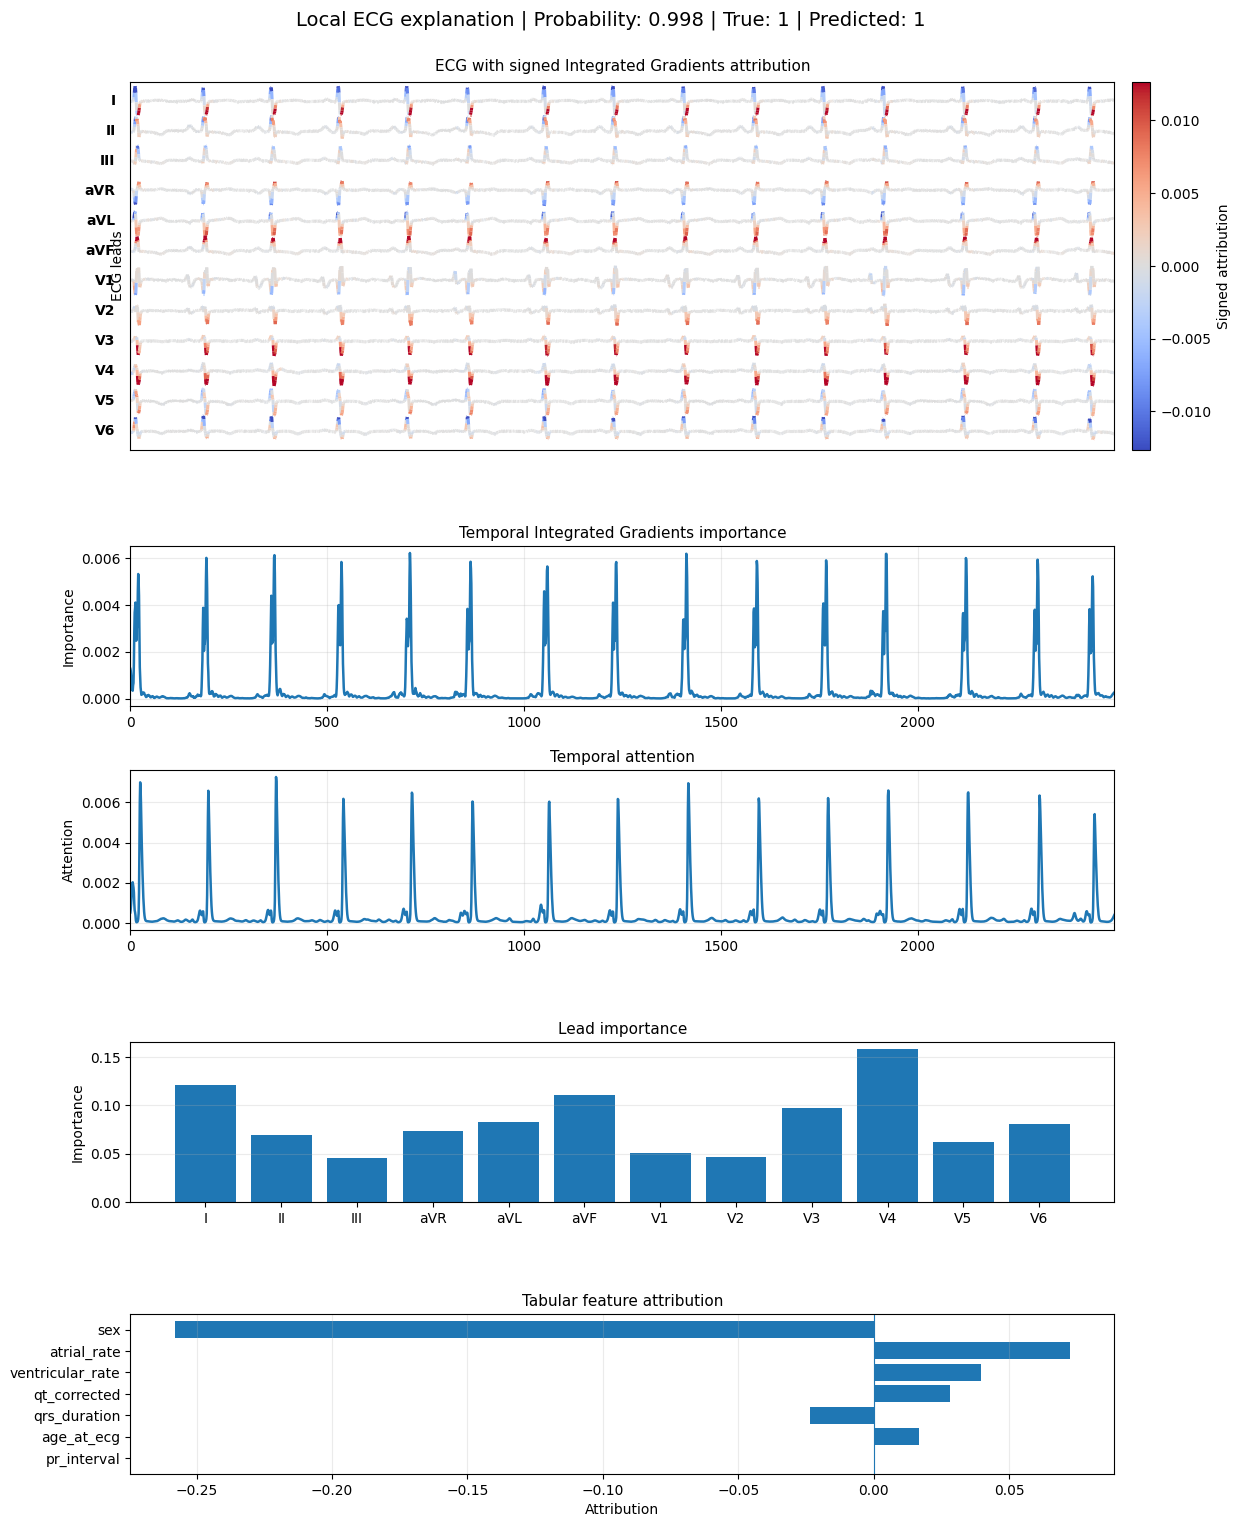

In [14]:
# true positive
result = explain_patient(
    model=model,
    dataset=pretrain_dataset,
    index=1872,
    device=device,
    n_steps=50,
    threshold=0.4
)
sample = pretrain_dataset[1872]
waveform = sample["waveform"].numpy()
fig = plot_local_explanation(
    result=result,
    waveform=waveform,
)
plt.show()

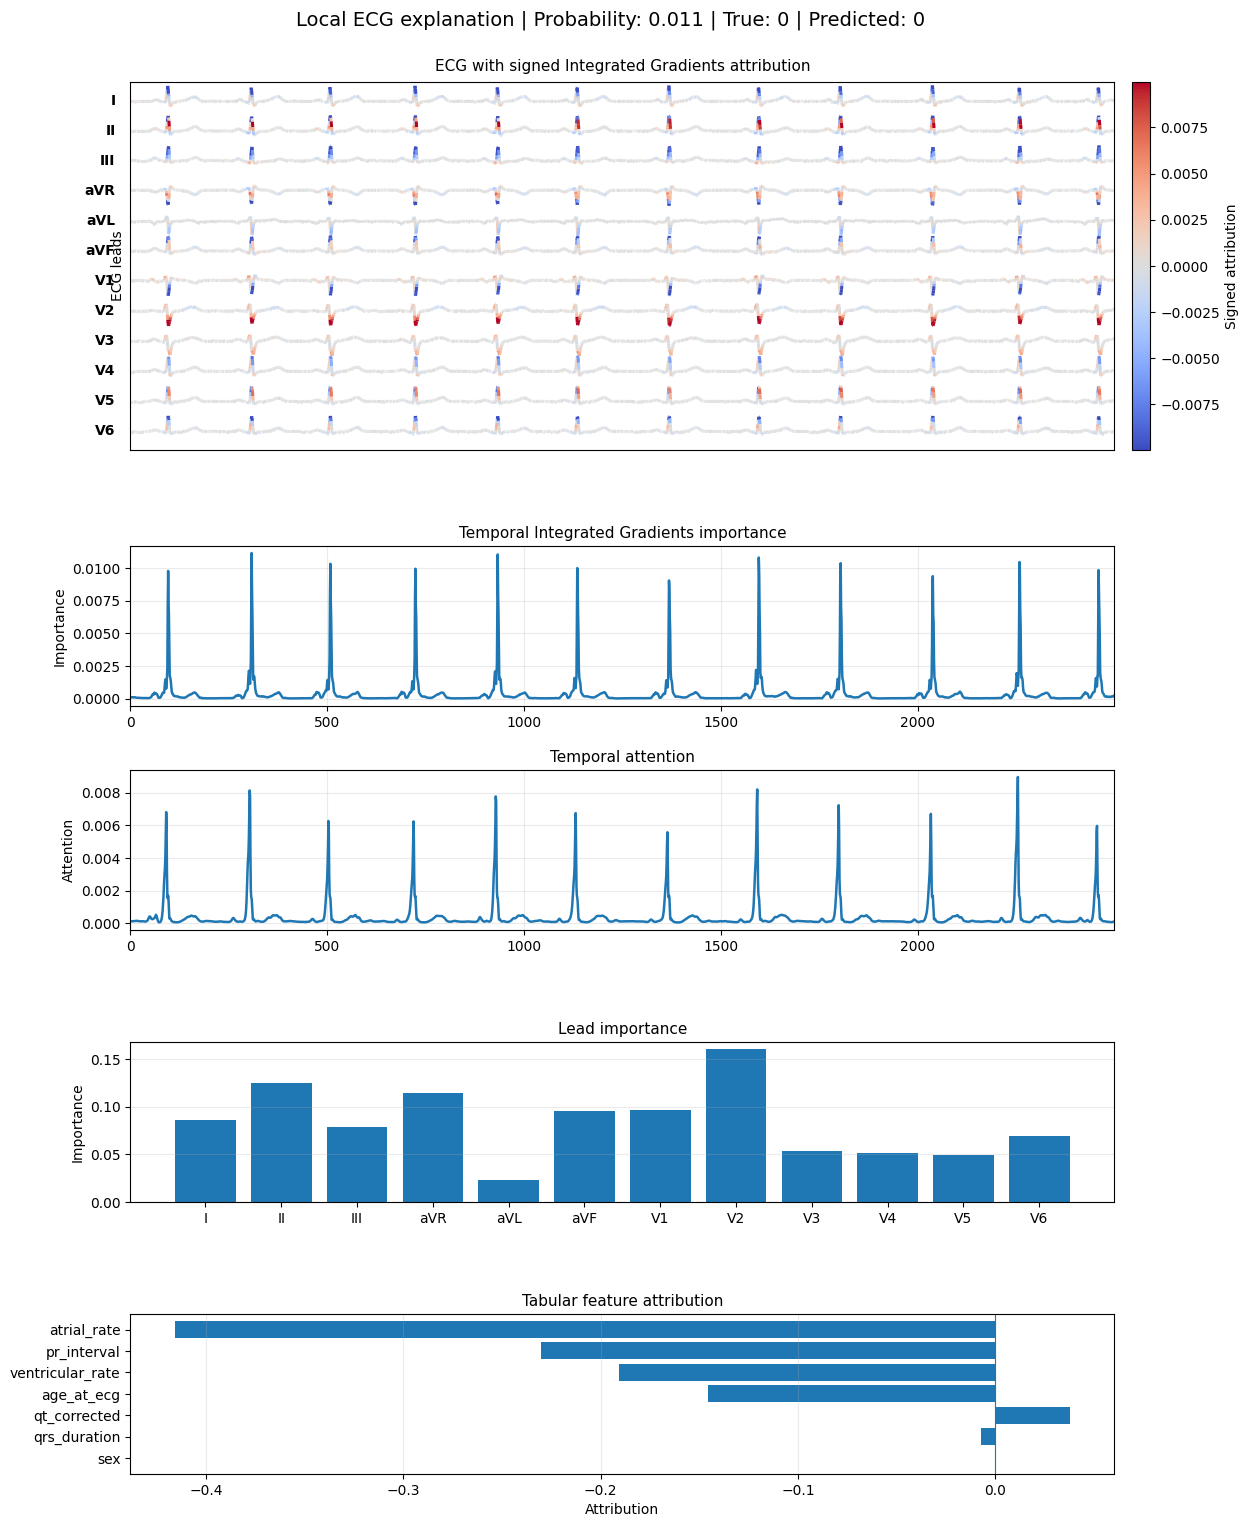

In [15]:
# true negative
result = explain_patient(
    model=model,
    dataset=pretrain_dataset,
    index=1190,
    device=device,
    n_steps=50,
    threshold=0.4
)
sample = pretrain_dataset[1190]
waveform = sample["waveform"].numpy()
fig = plot_local_explanation(
    result=result,
    waveform=waveform,
)
plt.show()

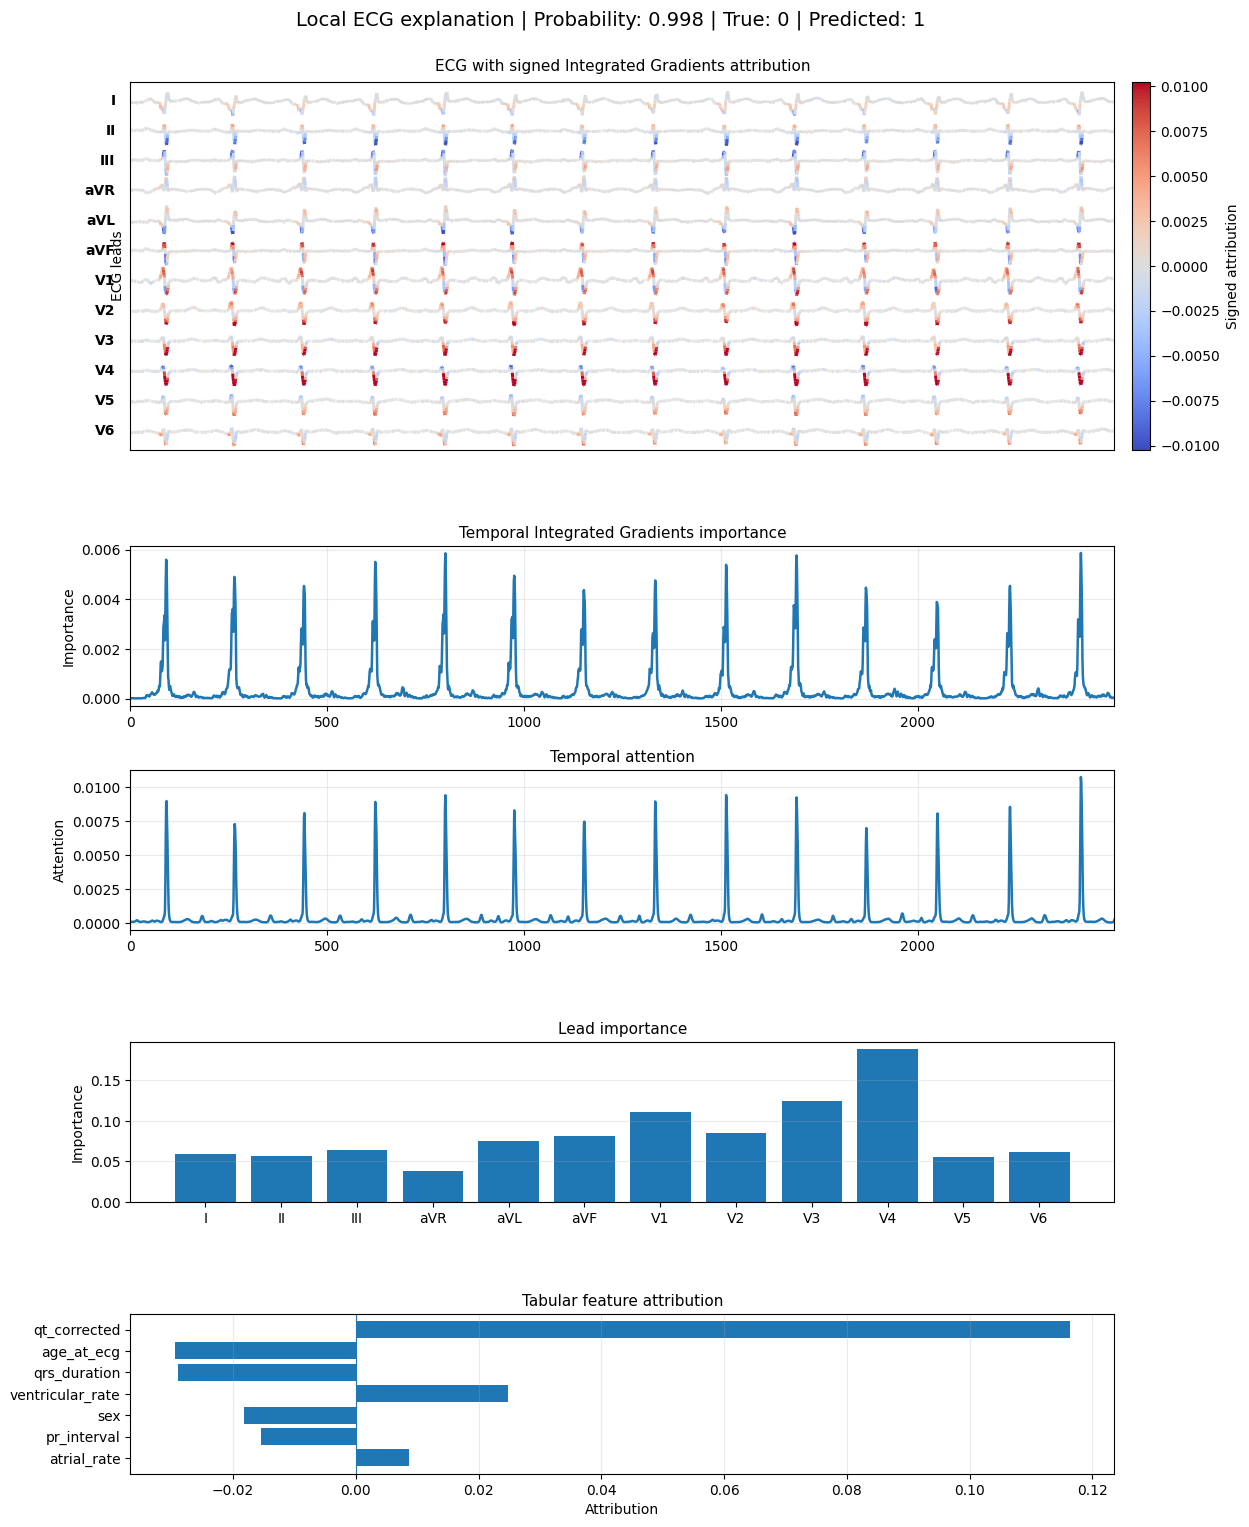

In [16]:
# false positive
result = explain_patient(
    model=model,
    dataset=pretrain_dataset,
    index=3740,
    device=device,
    n_steps=50,
    threshold=0.4
)
sample = pretrain_dataset[3740]
waveform = sample["waveform"].numpy()
fig = plot_local_explanation(
    result=result,
    waveform=waveform,
)
plt.show()

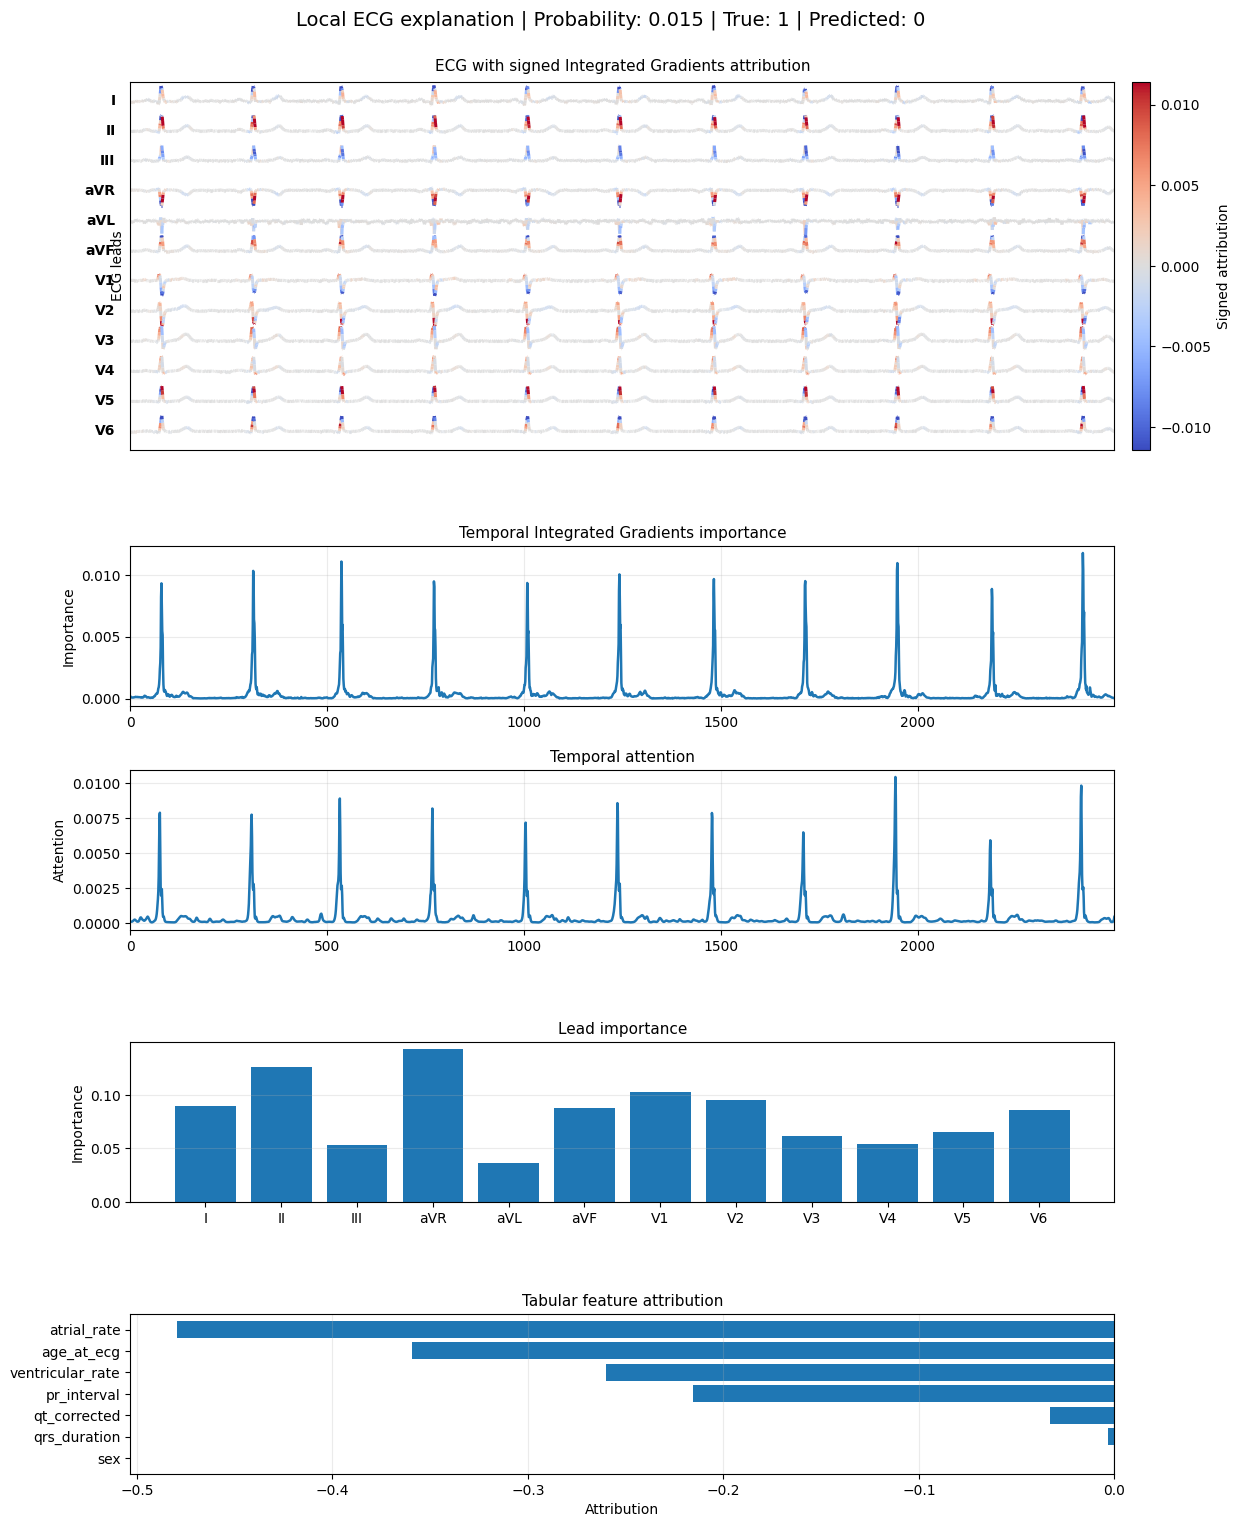

In [17]:
# false negative
result = explain_patient(
    model=model,
    dataset=pretrain_dataset,
    index=3349,
    device=device,
    n_steps=50,
    threshold=0.4
)
sample = pretrain_dataset[3349]
waveform = sample["waveform"].numpy()
fig = plot_local_explanation(
    result=result,
    waveform=waveform,
)
plt.show()

In [18]:
from master_thesis.deep_learning.explainability.global_analysis.leads import (
    compute_global_lead_importance,
)

result = compute_global_lead_importance(
    model=model,
    dataset=pretrain_dataset,
    target="shd_moderate_or_greater_flag",
    device=device,
    n_steps=50,
)

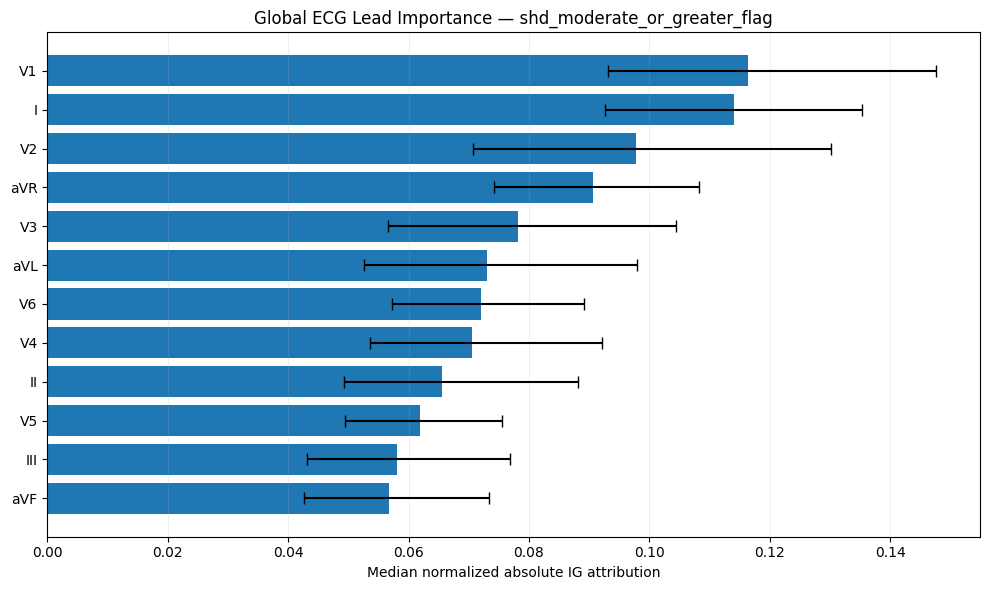

In [20]:
from master_thesis.deep_learning.explainability.visualization import plot_global_lead_importance

fig = plot_global_lead_importance(result)

plt.show()

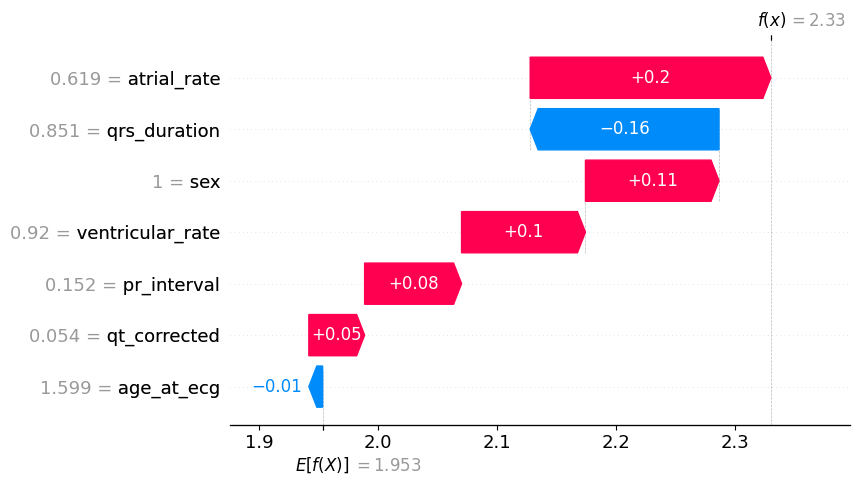

In [24]:
from master_thesis.deep_learning.explainability.common.shap import (
    compute_tabular_shap
)
import shap
from master_thesis.constants import COLUMNS

result = compute_tabular_shap(
    model=model,
    dataset=pretrain_dataset,
    index=0,
    target="shd_moderate_or_greater_flag",
    device=device,
)

explanation = shap.Explanation(
    values=result["shap_values"],
    base_values=result["expected_value"],
    data=result["tabular_values"],
    feature_names=COLUMNS,
)

shap.plots.waterfall(explanation)

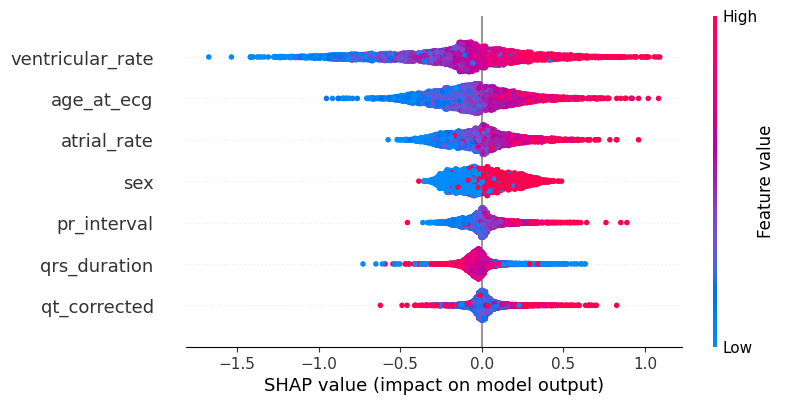

In [23]:
from master_thesis.deep_learning.explainability.common.shap import (
    compute_global_tabular_shap
)

global_result = compute_global_tabular_shap(
    model=model,
    dataset=pretrain_dataset,
    target="shd_moderate_or_greater_flag",
    device=device,
    explain_indices=range(len(pretrain_dataset)),
)
import shap

explanation = shap.Explanation(
    values=global_result["shap_values"],
    data=global_result["tabular_values"],
    feature_names=COLUMNS,
)

shap.plots.beeswarm(explanation)

In [25]:
from master_thesis.deep_learning.explainability.common.occlusion import (
    compute_ecg_occlusion,
)

sample = pretrain_dataset[0]

waveform = sample["waveform"].unsqueeze(0)

tabular = sample["tabular"].unsqueeze(0)

occlusion_result = compute_ecg_occlusion(
    model=model,
    waveform=waveform,
    tabular=tabular,
    target="shd_moderate_or_greater_flag",
    device=device,
    window_size=50,
    stride=25,
    baseline=0.0,
)

print("Original logit:", occlusion_result["original_logit"])
print(
    "Importance shape:",
    occlusion_result["occlusion_importance"].shape,
)
print(
    "Number of windows:",
    len(occlusion_result["window_effects"]),
)

Original logit: 2.3235666751861572
Importance shape: (2500,)
Number of windows: 99


In [50]:
MODEL_TYPE = "cnn_lstm"
model = ECGModel(diseases=pretrain_diseases, config=CONFIG_MAP[(MODEL_TYPE, "pretrain")])
for model_type, train_stage, seed, model_path in zip(
    models["model_type"],
    models["train_stage"],
    models["seed"],
    models["model_path"],
):
    if model_type == MODEL_TYPE and seed == SELECTED_SEED and train_stage == "pretrain":
        model.load_state_dict(torch.load(model_path, map_location=device)["model_state_dict"])
        model.to(device)
        model.eval()
        print(f"Loaded {train_stage} model for {model_type} with seed {seed} from {model_path}")

Loaded pretrain model for cnn_lstm with seed 123 from ../checkpoints/cnn_lstm_fusion_pretrain_123/best.pt


In [51]:
from master_thesis.deep_learning.explainability.common.grad_cam import (
    compute_cnn_grad_cam,
)

index = 0

sample = pretrain_dataset[index]

waveform = sample["waveform"].unsqueeze(0)

tabular = sample.get("tabular")

if tabular is not None:
    tabular = tabular.unsqueeze(0)

result = compute_cnn_grad_cam(
    model=model,
    waveform=waveform,
    target="shd_moderate_or_greater_flag",
    tabular=tabular,
    device=device,
)

In [52]:
print("Target:", result["target"])
print("Logit:", result["logit"])
print("Probability:", result["probability"])
print("Grad-CAM shape:", result["grad_cam"].shape)
print("Target layer:", result["target_layer"])

Target: shd_moderate_or_greater_flag
Logit: 2.634922981262207
Probability: 0.9330756068229675
Grad-CAM shape: (2500,)
Target layer: Conv1d


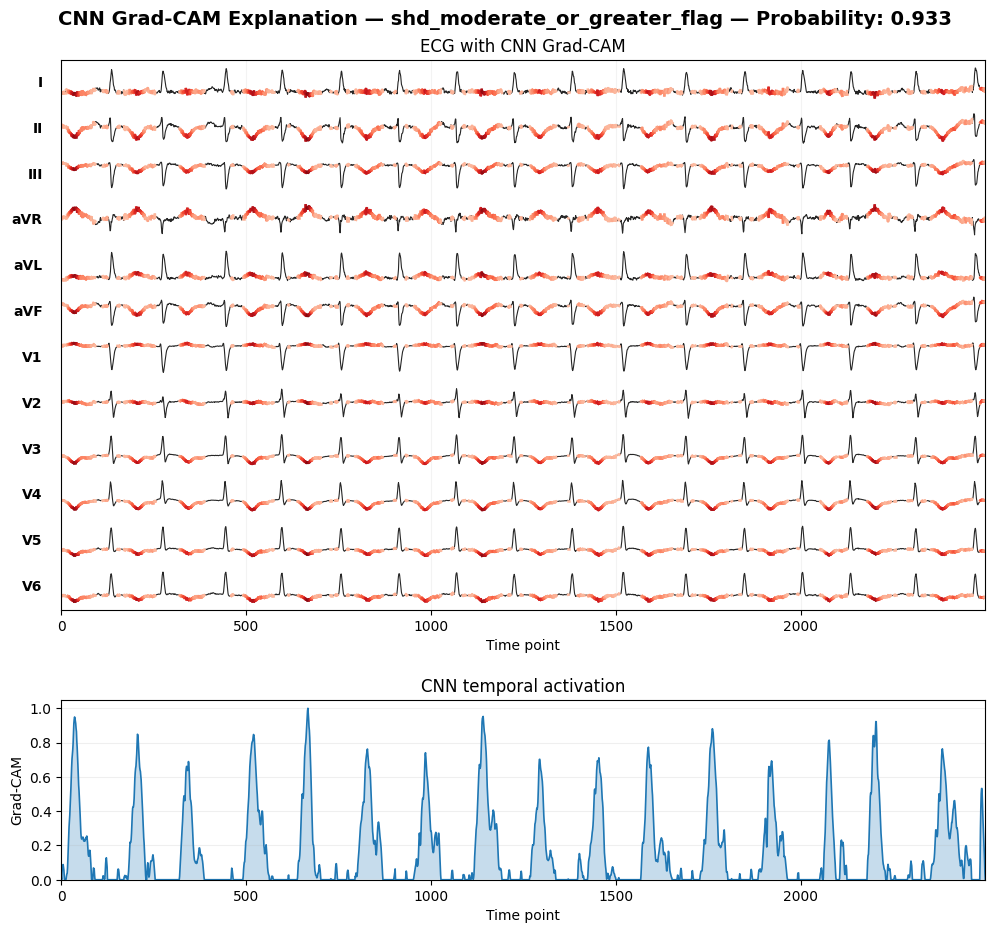

In [56]:
from master_thesis.deep_learning.explainability.visualization import (
    plot_cnn_grad_cam,
)

fig = plot_cnn_grad_cam(
    result=result,
    waveform=sample["waveform"],
)

plt.show()

In [60]:
from master_thesis.deep_learning.explainability.global_analysis.representations import (
    extract_rnn_representations,
    compute_pca_representation,
)

result = extract_rnn_representations(
    model=model,
    dataset=pretrain_dataset,
    target="shd_moderate_or_greater_flag",
    device=device,
)

pca_result = compute_pca_representation(result)

print(
    pca_result["embedding"].shape
)

print(
    pca_result["explained_variance_ratio"]
)

(5442, 2)
[0.43311247 0.08194573]


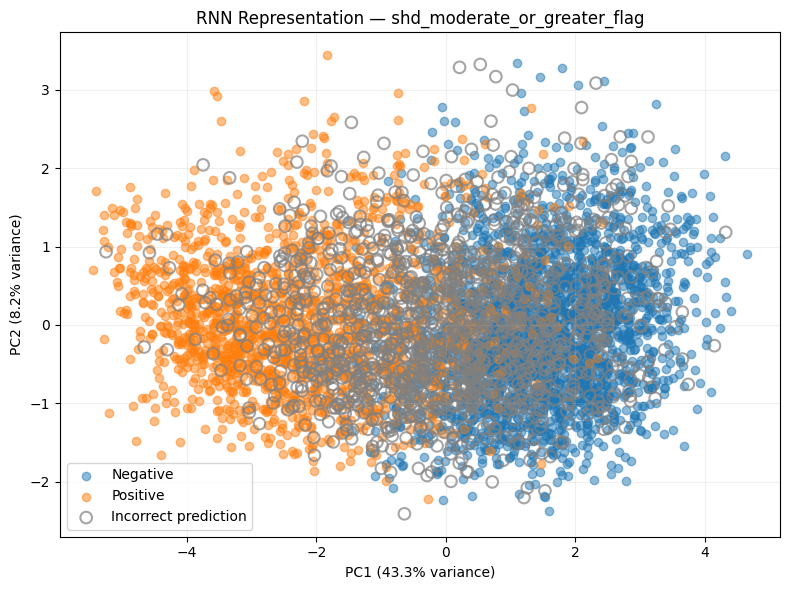

In [64]:
from master_thesis.deep_learning.explainability.visualization import (
    plot_rnn_representation,
)

fig = plot_rnn_representation(
    pca_result
)

plt.show()